# Non-Autonomous Terms and VF-b Test
This notebook uses the best candidates from SINDy_FHN.ipynb for fitting data.  These include the following options:
* Model - VF-b (most realistic FHN model)
* Optimizer - SSR
* feature_library - degree 3 polynomials

In [16]:
import math
import numpy as np
import functools
from scipy.integrate import odeint
from scipy import fft
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps
from fhn_models import fhn, fhn_c, fhn_vf_b
from gen_library_fit import GenLibraryFit

In [17]:
# The old, non-truncated autonomous term (can be a problem for large exponents).
# Params:
#   t (1d array): Time input vector
#   mag (float): The magnitude of the stimulus
def smooth_non_aut_old(t, mag=0.12):
    return 2. * mag / (1. + np.exp((25*np.sin(0.02*t))**2))

# A differentiable non-autonomous term truncated from the Taylor series of the above term.
# Params:
#   t (1d array): Time input vector
#   mag (float): The magnitude of the stimulus
def smooth_non_aut(t, mag=0.12):
    return 2. * mag / (2. + (200.*np.sin(0.02*t))**4)

# Logical step function non-autonomous term.
# Params:
#   t (1d array): Time input vector
#   period (float): The period of the stimulus
#   dur (float): The time duration of the stimulus
#   mag (float): The magnitude of the stimulus
def logical_non_aut(t, period=155.0, dur=5.0, mag=0.12):
    stimulus = mag * (np.mod(t, period) <= dur)
    return stimulus

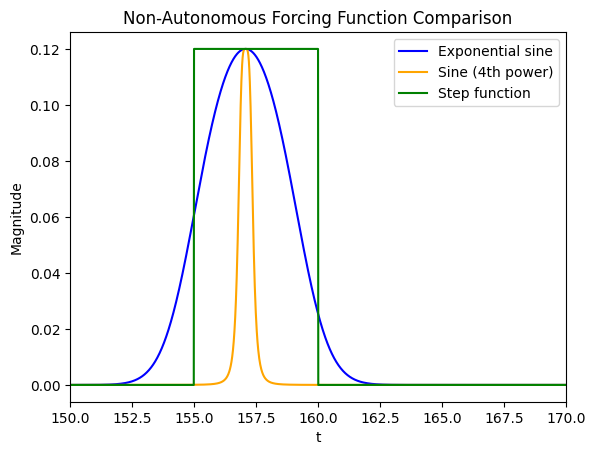

In [52]:
# Compare the forcing functions. Note that we can't actually use the exponential since it will encounter overflow for the peak tightness
# that we need; instead, take part of the Taylor series, then throw out the terms we don't need while still maintaing a representative shape.
t = np.arange(0,500,0.01)
plt.plot(t, smooth_non_aut_old(t), color = 'blue', label='Exponential sine')
plt.plot(t, smooth_non_aut(t), color='orange', label='Sine (4th power)')
plt.plot(t, logical_non_aut(t), color='green', label='Step function')
plt.xlim(150,170)
plt.xlabel('t')
plt.ylabel('Magnitude')
plt.title('Non-Autonomous Forcing Function Comparison')
plt.legend()

# 1.) VF-FHN
Now, let's try fitting the above with some non-autonomous terms included.

In [71]:
# Time step and initial values; seems like 0-600 is minimum timeframe needed to identify dynamics
dt = 0.01
t_vf_b = np.arange(0,4000,dt)
x_0_vf_b = np.array([0,0])

In [ ]:
# (Uncomment to determine the optimal period)

# fhn_vf_b_part = functools.partial(fhn_vf_b, alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0)

# # Compare how different stimulus periods affect the FHN VF-b waveforms.
# for i in range(0,20):
#     cur_period = 350. + i
#     non_aut_func = functools.partial(logical_non_aut, period=cur_period, dur=5.0, mag=0.12)
#     cur_states_fhn = odeint(fhn_vf_b_part, x_0_vf_b, t_vf_b, args=(non_aut_func,), hmax=0.1)

#     cur_df_states_fhn = pd.DataFrame(cur_states_fhn, columns=['u','v'])
#     cur_u_fhn = cur_df_states_fhn['u'].tolist()

#     plt.plot(t_vf_b, cur_u_fhn)
#     plt.title(f"VF-FHN with Stimulus Period {cur_period:.0f} Time Units")
#     plt.gcf().set_size_inches(10, 2.5) # Change plot size so we quickly see differences in waveforms
#     plt.show()

Based on the plots above, T = 361 time units gives the best result, with the VF-b variant of FHN seeming very sensitive to the correct stimulus period. Any variation from this value results in alternans and/or the stimulus occurring in the middle of an AP. Here is a compilation of the optimal period for various sets of parameters:

* alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0 — T = 361
* alpha = 0.2, beta = 1.03, gamma = 0.31, delta = 0.0, eps = 0.003, theta = -0.05, mu = 1.1 — T = 765

In [74]:
# Generate the data using our non-autonomous term. Note that the period is very sensitive per the above experiment, so we must be careful in our selection of its value.
non_aut_func_vf_b = functools.partial(logical_non_aut, period=361, dur=5.0, mag=0.12)

states_vf_b = odeint(fhn_vf_b_part, x_0_vf_b, t_vf_b, args=(non_aut_func_vf_b,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> non_aut_func_vf_b

In [104]:
# Run SINDy on VF-FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up
# TODO How to remove these terms?
opt_vf_b = ps.SSR(alpha=0.00001, normalize_columns=True)
model_vf_b = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_b)
model_vf_b.fit(states_vf_b, t=t_vf_b)
model_vf_b.print(precision=5)

(u)' = 0.00127 1 + 0.88871 u + 0.08787 v + -1.13470 u^2 + -5.60376 u v + -1.05161 v^2 + 0.24381 u^3 + 4.76225 u^2 v + 5.89494 u v^2 + 2.16712 v^3
(v)' = -0.00081 1 + 0.00402 u + -0.00300 u^2


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

Based on the result above, it seems we can identify $\dot{v}$, but not $\dot{u}$, when a stimulus is applied and not accounted for by SINDy.  This is to be expected since the stimulus term is only added to the $\dot{u}$ equation.

Number of SINDy terms for u', v': (10, 3)
Number of exact terms for u', v': (4, 4)

SINDy coefficients:
(u)' = 0.00127 1 + 0.88871 u + 0.08787 v + -1.13470 u^2 + -5.60376 u v + -1.05161 v^2 + 0.24381 u^3 + 4.76225 u^2 v + 5.89494 u v^2 + 2.16712 v^3
(v)' = -0.00081 1 + 0.00402 u + -0.00300 u^2

Exact coefficients:
u' = -0.22 u + 0.42 u^2 + -1.0 uv + -0.2 u^3 + 0.0 v^3
v' = 0.0515 1 + 0.3193 u + -0.00309 v + -1.03 u^2 + 0.0 v^3


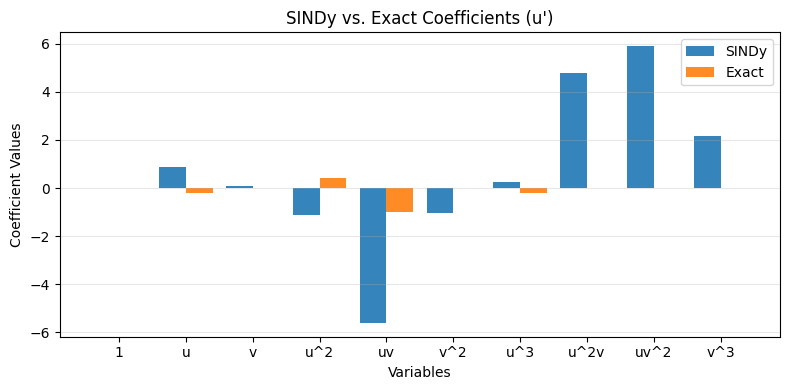

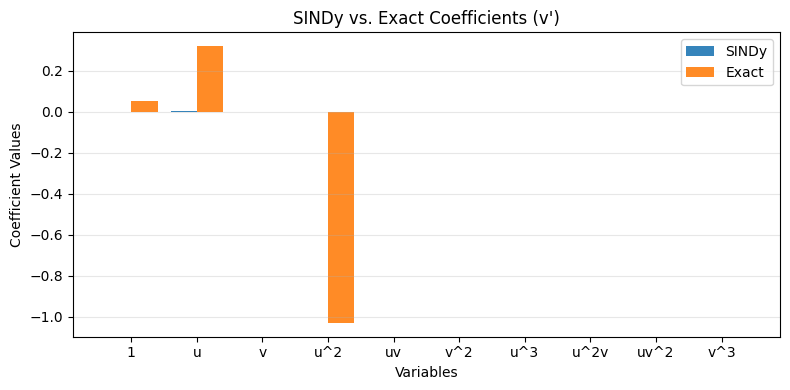

In [117]:
# Order of coefficients: 1, u, v, u^2, uv, v^2, u^3, u^2v, uv^2, v^3
variables = ["1", "u", "v", "u^2", "uv", "v^2", "u^3", "u^2v", "uv^2", "v^3"]
coef_sindy = model_vf_b.coefficients()
coef_exact = np.array([[0, -0.22, 0, 0.42, -1.0, 0, -0.2, 0, 0, 0],
                       [0.0515, 0.3193, -0.00309, -1.03, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
x = np.arange(len(coef_sindy[0]))

# Compare number of terms in the SINDy model to the exact coefficients.
precision = 5
tol = 10**(-precision)
print(f"Number of SINDy terms for u\', v\': ({np.sum(np.abs(coef_sindy[0]) > tol)}, {np.sum(np.abs(coef_sindy[1]) > tol)})")
print(f"Number of exact terms for u\', v\': ({np.sum(np.abs(coef_exact[0]) > tol)}, {np.sum(np.abs(coef_exact[1]) > tol)})")

# Compare the SINDy and exact coefficients.
print("\nSINDy coefficients:")
model_vf_b.print(precision=precision)
print("\nExact coefficients:")
for i in range(len(coef_exact)):
    eqn = ""
    eqn += ("u\' = " if i == 0 else "v\' = ")
    for j in range(len(coef_exact[0])):
        if (np.abs(coef_exact[i][j]) > tol) and (j < len(coef_exact[0]) - 1):  # Print only nonzero coefficients.
            eqn += f"{coef_exact[i][j]} {variables[j]} + "
        elif (j == len(coef_exact[0]) - 1):  # Handle the last term separately.
            eqn += f"{coef_exact[i][j]} {variables[j]}"
    print(eqn)


# Use bar chart to compare the SINDy and exact coefficient values (for u').
width = 0.4
plt.figure(figsize=(8, 4))
plt.bar(x - width/2, coef_sindy[0], width=width, alpha=0.9, label='SINDy')
plt.bar(x + width/2, coef_exact[0], width=width, alpha=0.9, label='Exact')

plt.title('SINDy vs. Exact Coefficients (u\')')
plt.ylabel('Coefficient Values')
plt.xlabel('Variables')
plt.xticks(x, variables)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)


# Use bar chart to compare the SINDy and exact coefficient values (for v').
width = 0.4
plt.figure(figsize=(8, 4))
plt.bar(x - width/2, coef_sindy[1], width=width, alpha=0.9, label='SINDy')
plt.bar(x + width/2, coef_exact[1], width=width, alpha=0.9, label='Exact')

plt.title('SINDy vs. Exact Coefficients (v\')')
plt.ylabel('Coefficient Values')
plt.xlabel('Variables')
plt.xticks(x, variables)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)

Text(0.5, 1.0, 'Values of u vs. v')

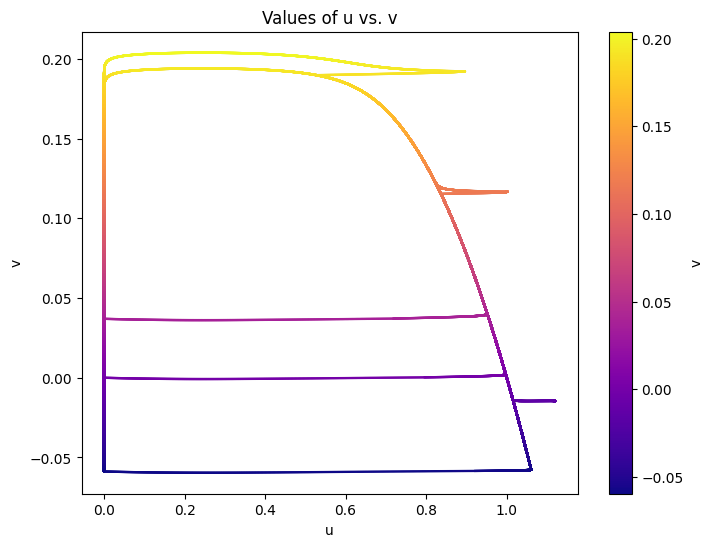

In [59]:
# Plot results - u vs. v
df_states_vf_b = pd.DataFrame(states_vf_b, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf_b['u'], 
    df_states_vf_b['v'], 
    c=df_states_vf_b['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.0011986923255775776, 0.0023947880389979764, 0.0035883301889430516, 0.004779357691511454, 0.005967907962655165, 0.007154030534293182, 0.00833777421321259, 0.009519182400615448, 0.010698288911688088]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


Text(0.5, 1.0, 'Voltage vs. Time (VF-FHN)')

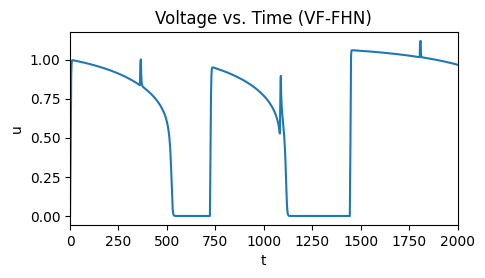

In [60]:
# Plot results - u vs. t
u_vf_b = df_states_vf_b['u'].tolist()
print(u_vf_b[0:10])
print(t_vf_b[0:10])

plt.figure(figsize=(5, 2.5))
plt.plot(t_vf_b,u_vf_b)
plt.xlim(0, 2000)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (VF-FHN)')

# 2.) FHN
Now, fit standard FHN model with non-autonomous terms.

In [25]:
# Standard FHN parameters
t_fhn = np.arange(0,2000,dt)
x_0_fhn = np.array([0,0])
states_fhn = odeint(fhn, x_0_fhn, t_fhn, args=(logical_non_aut,), hmax=0.1) # Test code --> lambda t: 0         Actual code --> logical_non_aut

In [26]:
# Run SINDy on FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_fhn = ps.SSR(alpha=0.00001, normalize_columns=True)
model_fhn = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn)
model_fhn.print(precision=5)

(u)' = 0.03218 1 + 0.54900 u + 0.94559 v + -0.10030 u^2 + -7.80797 u v + -22.56224 v^2 + -0.48986 u^3 + 5.83089 u^2 v + 21.42264 u v^2 + 61.47220 v^3
(v)' = 0.00500 u + -0.01000 v + 0.00001 v^3


In [27]:
# TODO Why does using standard function library (e.g., removing feature_library argument) result in fewer extraneous terms?
model_fhn = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_fhn)
model_fhn.fit(states_fhn, t=t_fhn)
model_fhn.print(precision=5)

(u)' = 0.03218 1 + 0.54900 u + 0.94559 v + -0.10030 u^2 + -7.80797 u v + -22.56224 v^2 + -0.48986 u^3 + 5.83089 u^2 v + 21.42264 u v^2 + 61.47220 v^3
(v)' = 0.00500 u + -0.01000 v + 0.00001 v^3


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 uv - 1 u^3 \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1uv - 1 u^3 \\
    \dot{v} &= - 0.01 + 0.005 u - 0.01v \\
\end{align}

Even with the simpler FHN model, we get the same result as with VF-FHN—the stimulus term must be taken into account in order for the $\dot{u}$ equation to be correctly identified.

Text(0.5, 1.0, 'Values of u vs. v')

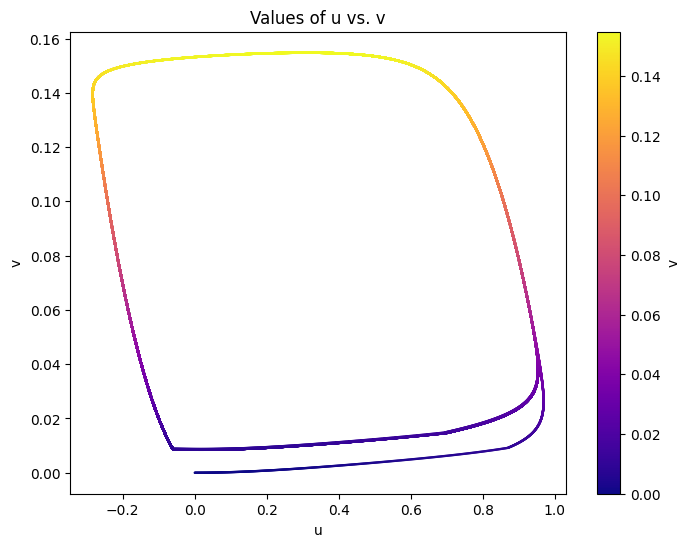

In [28]:
# Plot results - u vs. v
df_states_fhn = pd.DataFrame(states_fhn, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_fhn['u'], 
    df_states_fhn['v'], 
    c=df_states_fhn['v'],  # Color shade controlled by v column
    s=0.5,  # Marker size
    cmap='plasma'
)

# Add colorbar for the v values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.0, 0.0011988115034597003, 0.002395261989364361, 0.003589390000766398, 0.004781233289104065, 0.005970822003553176, 0.0071582013149533285, 0.008343415251760685, 0.009526505707204933, 0.010707503206621026]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


Text(0.5, 1.0, 'Voltage vs. Time (FHN)')

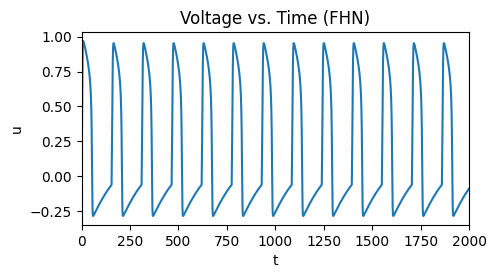

In [48]:
# Plot results - u vs. t
u_fhn = df_states_fhn['u'].tolist()
print(u_vf_b[0:10])
print(t_fhn[0:10])

plt.figure(figsize=(5, 2.5))
plt.plot(t_fhn,u_fhn)
plt.xlim(0, 2000)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (FHN)')

# Experimental Section
Includes subtraction of logical_non_aut before passing to SINDy, FFT of voltage response, etc.

[0.0, 0.0011994098198587781, 0.002397651144048946, 0.0035947547308883116, 0.0047907558187071835, 0.005985674083706682, 0.007179547898377901, 0.008372413867041097, 0.009564306477421403, 0.010755250757803373]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


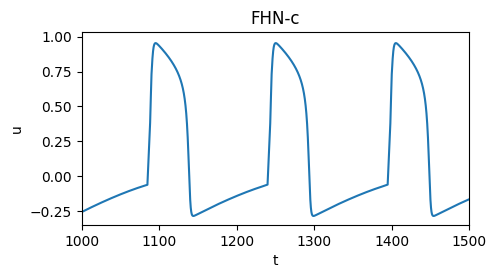

Text(0.5, 1.0, 'FHN-c (Non-Autonomous Term Subtracted)')

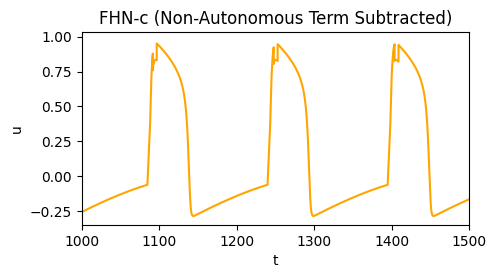

In [53]:
u_fhn = df_states_fhn['u'].tolist()
print(u_fhn[0:10])
print(t_fhn[0:10])

# Plot result - u vs. t
plt.figure(figsize=(5, 2.5))
plt.plot(t_fhn,u_fhn)
plt.xlim(1000, 1500)
plt.xlabel('t')
plt.ylabel('u')
plt.title('FHN-c')
plt.show()

# Now subtract the non-autonomous term to try to ID the original FHN dynamics. Because of the nonlinear effects, the spike at the peak will be slightly off, making this method not work particularly well.
plt.figure(figsize=(5, 2.5))
plt.plot(t_fhn,u_fhn - logical_non_aut(t_fhn, period=156, dur=5, mag=0.12), color='orange')
plt.xlim(1000, 1500)
plt.xlabel('t')
plt.ylabel('u')
plt.title('FHN-c (Non-Autonomous Term Subtracted)')

Text(0.5, 1.0, 'FFT of FHN u Values')

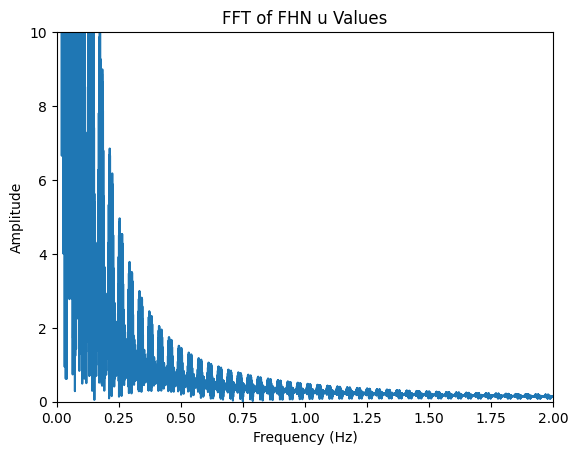

In [31]:
# Test analyzing time series in frequency space to see if we can tease out the non-autonomous signal.
# TODO Figure out what whether scipy.fft is being used incorrectly
w_fhn = fft.fft(u_fhn)
w_fhn = np.abs(w_fhn[0:len(w_fhn)//2]) # Take the first half of the FFT result, making sure to make all values real.
w = np.arange(0, 10, dt / 100.)
plt.plot(w, w_fhn)
plt.ylim(0, 10)
plt.xlim(0, 2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT of FHN u Values')

# 3.) Using GeneralizedLibrary to ID Non-Autonomous Terms
We can use pySINDy's `GeneralizedLibrary` class to combine multiple `CustomLibrary` instances while also restricting which functions can apply to which equations using the argument inputs_per_library. This is useful since we know that the time-dependent term will only appear in the $u$ (voltage) equation.

In [32]:
# TODO Calling w/ functools.partial() results in no .__code__ on pySINDy call, so have to define functions explicitly; would like to refactor in better way.
# Define battery of similar non-autonomous terms on which to test SINDy with the GeneralizedLibrary implementation above.
# Recall - 0.12 approximately optimal stimulus (for period 0.08 * 1.5 --> 0.12).
func_test = lambda t: (np.sin(0.01*t))**2
def func_log(t):
    return logical_non_aut(t, period=155.0, dur=5.0, mag=0.12)
def func_smooth(t):
    return smooth_non_aut(t, mag=0.12)
def func_smooth_old(t):
    return smooth_non_aut_old(t, mag=0.12)
funcs = [func_test, func_log, func_smooth, func_smooth_old]

### a.) FHN Test

In [33]:
# Test fit with same data and fitting non-autonomous terms.
for func in funcs:
    print(f"Fitting with function: {func.__name__}")
    cur_gen_library_a = GenLibraryFit(dt, func, func, fhn_variant="standard")
    cur_gen_library_a.fit()
    print('\n\n')

Fitting with function: <lambda>
(u)' = -0.10000 u + 1.10000 u^2 + -1.00000 u^3 + -1.00000 v + 1.00000 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_log
(u)' = -0.09994 u + 1.09966 u^2 + -0.99975 u^3 + -0.99983 v + 0.00001 1 + 0.99802 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth
(u)' = -0.10001 u + 1.10014 u^2 + -0.99616 u^3 + -1.00008 v + 0.99984 f_td(t)
(v)' = 0.00500 u + 0.00001 u^3 + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth_old
(u)' = -0.10000 u + 1.10000 u^2 + -1.00000 u^3 + -1.00000 v + 1.00000 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1





Actual equations for comparison:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 u^3 - 1 v + f_{td}(t) \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

In [34]:
# TODO Can't correctly ID w/ similar-looking non-autonomous functions; need to look into further.
# Test fit with different data and fitting non-autonomous terms.
print(f"Fitting logical_non_aut data with smooth_non_aut fit")
cur_gen_library_a = GenLibraryFit(dt, func_log, func_smooth, fhn_variant="standard")
cur_gen_library_a.fit()
print('\n\n')

Fitting logical_non_aut data with smooth_non_aut fit
(u)' = -0.05388 u + 1.27544 u^2 + -1.25628 u^3 + -1.25923 v + 0.01859 1 + 0.21402 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1





Text(0.5, 1.0, 'Voltage vs. Time (FHN)')

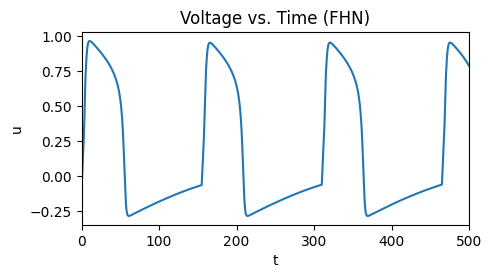

In [35]:
# Make sure voltage plots look correct.
plt.figure(figsize=(5, 2.5))
plt.plot(cur_gen_library_a.states_fhn_td[:, 2], cur_gen_library_a.states_fhn_td[:, 0], label='u vs. t')
plt.xlim(0, 500)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (FHN)')

### b.) FHN-c Test

In [36]:
# Test fit with same data and fitting non-autonomous terms.
for func in funcs:
    print(f"Fitting with function: {func.__name__}")
    cur_gen_library_b = GenLibraryFit(dt, func, func, fhn_variant="cardiac")
    cur_gen_library_b.fit()
    print('\n\n')

Fitting with function: <lambda>
(u)' = 0.01798 u + 0.04450 u^2 + -0.10704 u^3 + -0.20927 v + 0.06649 1 + 0.15733 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_log
(u)' = -0.12523 u + 0.46219 u^2 + -0.38427 u^3 + -0.22112 v + 0.03290 1 + 1.07123 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth
(u)' = -0.10608 u + 1.05063 u^2 + 0.26547 u^3 + 1.00123 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1



Fitting with function: func_smooth_old
(u)' = -0.10022 u + 0.45282 u^2 + -0.41368 u^3 + -0.29392 v + 0.04402 1 + 0.94680 f_td(t)
(v)' = 0.00500 u + -0.01000 v
(t)' = 1.00000 1





Actual equations for comparison:

\begin{align}
    \dot{u} &= - 0.1 u + 1.1 u^2 - 1 u^3 - 1 u v + f_{td}(t) \\
    \dot{v} &= 0.005 u - 0.01v \\
\end{align}

Text(0.5, 1.0, 'Voltage vs. Time (FHN-c)')

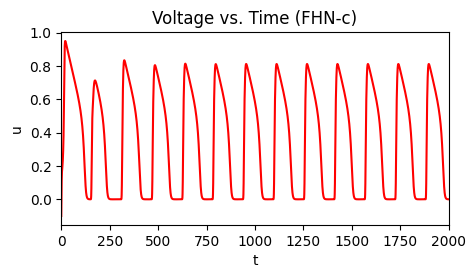

In [37]:
# Make sure voltage plots look correct.
plt.figure(figsize=(5, 2.5))
plt.plot(cur_gen_library_b.states_fhn_td[:, 2], cur_gen_library_b.states_fhn_td[:, 0], label='u vs. t', color='red')
plt.xlim(0, 2000)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (FHN-c)')

### c.) VF-FHN Test

In [38]:
def func_log_vf(t):
    return logical_non_aut(t, period=361.0, dur=5.0, mag=0.12)
funcs_vf = [func_log_vf]

# Test fit with same data and fitting non-autonomous terms.
for func in funcs_vf:
    print(f"Fitting with function: {func.__name__}")
    cur_gen_library_c = GenLibraryFit(dt, func, func, fhn_variant="vf")
    cur_gen_library_c.fit()
    print('\n\n')

Fitting with function: func_log_vf
(u)' = -0.18061 u + 0.47306 u^2 + -0.30063 u^3 + -0.07870 v + 0.00624 1 + 1.28148 f_td(t)
(v)' = 0.00705 u + -0.00500 u^2 + -0.00146 1
(t)' = 1.00000 1





Actual equations for comparison:

\begin{align}
    \dot{u} &= - 0.2 u + 1.2 u^2 - u v - 1 u^3 + f_{td}(t) \\
    \dot{v} &= -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

Text(0.5, 1.0, 'Voltage vs. Time (VF-b FHN)')

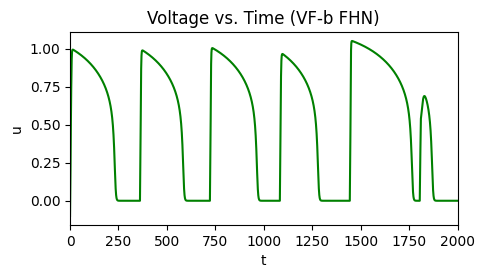

In [39]:
# TODO VF-b has parameters slightly off based on t~1750
# Make sure voltage plots look correct.
plt.figure(figsize=(5, 2.5))
plt.plot(cur_gen_library_c.states_fhn_td[:, 2], cur_gen_library_c.states_fhn_td[:, 0], label='u vs. t', color='green')
plt.xlim(0, 2000)
plt.xlabel('t')
plt.ylabel('u')
plt.title('Voltage vs. Time (VF-b FHN)')

# 4.) Stimulus Amplitude Comparison

In [40]:
# (Uncomment to determine the optimal stimulus amplitude)

# Plot time-dependent FHN states for different stimulus amplitudes. The optimal amplitude will be around 1.5x to 2x the 
# first threshold amplitude that gives a good waveform (so ~1.5 * 0.08 = 0.12).
# for amp in np.arange(0.0,0.2,0.02):
#     states_fhn_td = odeint(fhn, cur_gen_library_a.x_0_fhn_td, cur_gen_library_a.t_fhn_td, args=(functools.partial(logical_non_aut, period=155.0, dur=5.0, mag=amp),), hmax=0.1) # Test --> lambda t: 0       Actual --> logical_non_aut
#     plt.plot(states_fhn_td[:,0:1], label='u')
#     plt.ylim(-0.5,1.5)
#     plt.xlim(0,50000)
#     plt.title(f"FHN Time-Dependent States with Stimulus Amplitude {amp:.2f}")
#     plt.show()